### 第三次作業：雙樣本 T 檢定的 p-value 分佈

姓名：陳維萱</font>

學號：411180015</font>

作品目標：統計應用上經常需要檢定兩組資料的母體（來源）平均數是否相等，一般稱為雙樣本 T 檢定（Two-Sample T test），寫成：




 H0: $\mu$ <sub>1</sub> = $\mu$ <sub>2</sub> 

 Ha: $\mu$ <sub>1</sub> $\neq$ $\mu$ <sub>2</sub> 


檢定統計量為：
$$
t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$


以統計教科書上的經典內容——假設檢定，透過模擬實驗，將雙樣本 T 檢定的檢定統計量與 p 值分佈視覺化，以深入理解其統計特性。首先，驗證檢定統計量是否符合理論上的 T 分配，並探討在母體平均數相等的假設下，p 值應滿足均勻分佈的特性。接著，設定不同的母體平均數以比較 p 值分佈，並分析平均數差異對檢定結果的影響。隨後，計算不同樣本數下的檢定力，以觀察樣本數對檢定靈敏度的影響。藉由改變變數並觀察分佈變化，將檢定過程中的理論與數據直觀呈現。

<hr>
<font color=#EF9520> （一） 「雙（獨立）樣本 T 檢定」觀察抽樣M次的PDF及CDF圖</font>

1. 當兩組樣本來自 H0 的假設，兩組樣本皆來自常態分配N(0, 1)，執行抽樣共 100次，每次計算出一個檢定統計量 t，繪製其直方圖及ECDF圖，並分別套上理論的 T 分配 PDF 與 CDF 函數。
2. 當兩組樣本來自 H0 的假設，兩組樣本皆來自常態分配N(0, 1)，執行抽樣共 1000次，每次計算出一個檢定統計量 t，繪製其直方圖及ECDF圖，並分別套上理論的 T 分配 PDF 與 CDF 函數。
3. 當兩組樣本來自 H0 的假設，兩組樣本皆來自常態分配N(0, 1)，執行抽樣共 10000次，每次計算出一個檢定統計量 t，繪製其直方圖及ECDF圖，並分別套上理論的 T 分配 PDF 與 CDF 函數。
<hr>

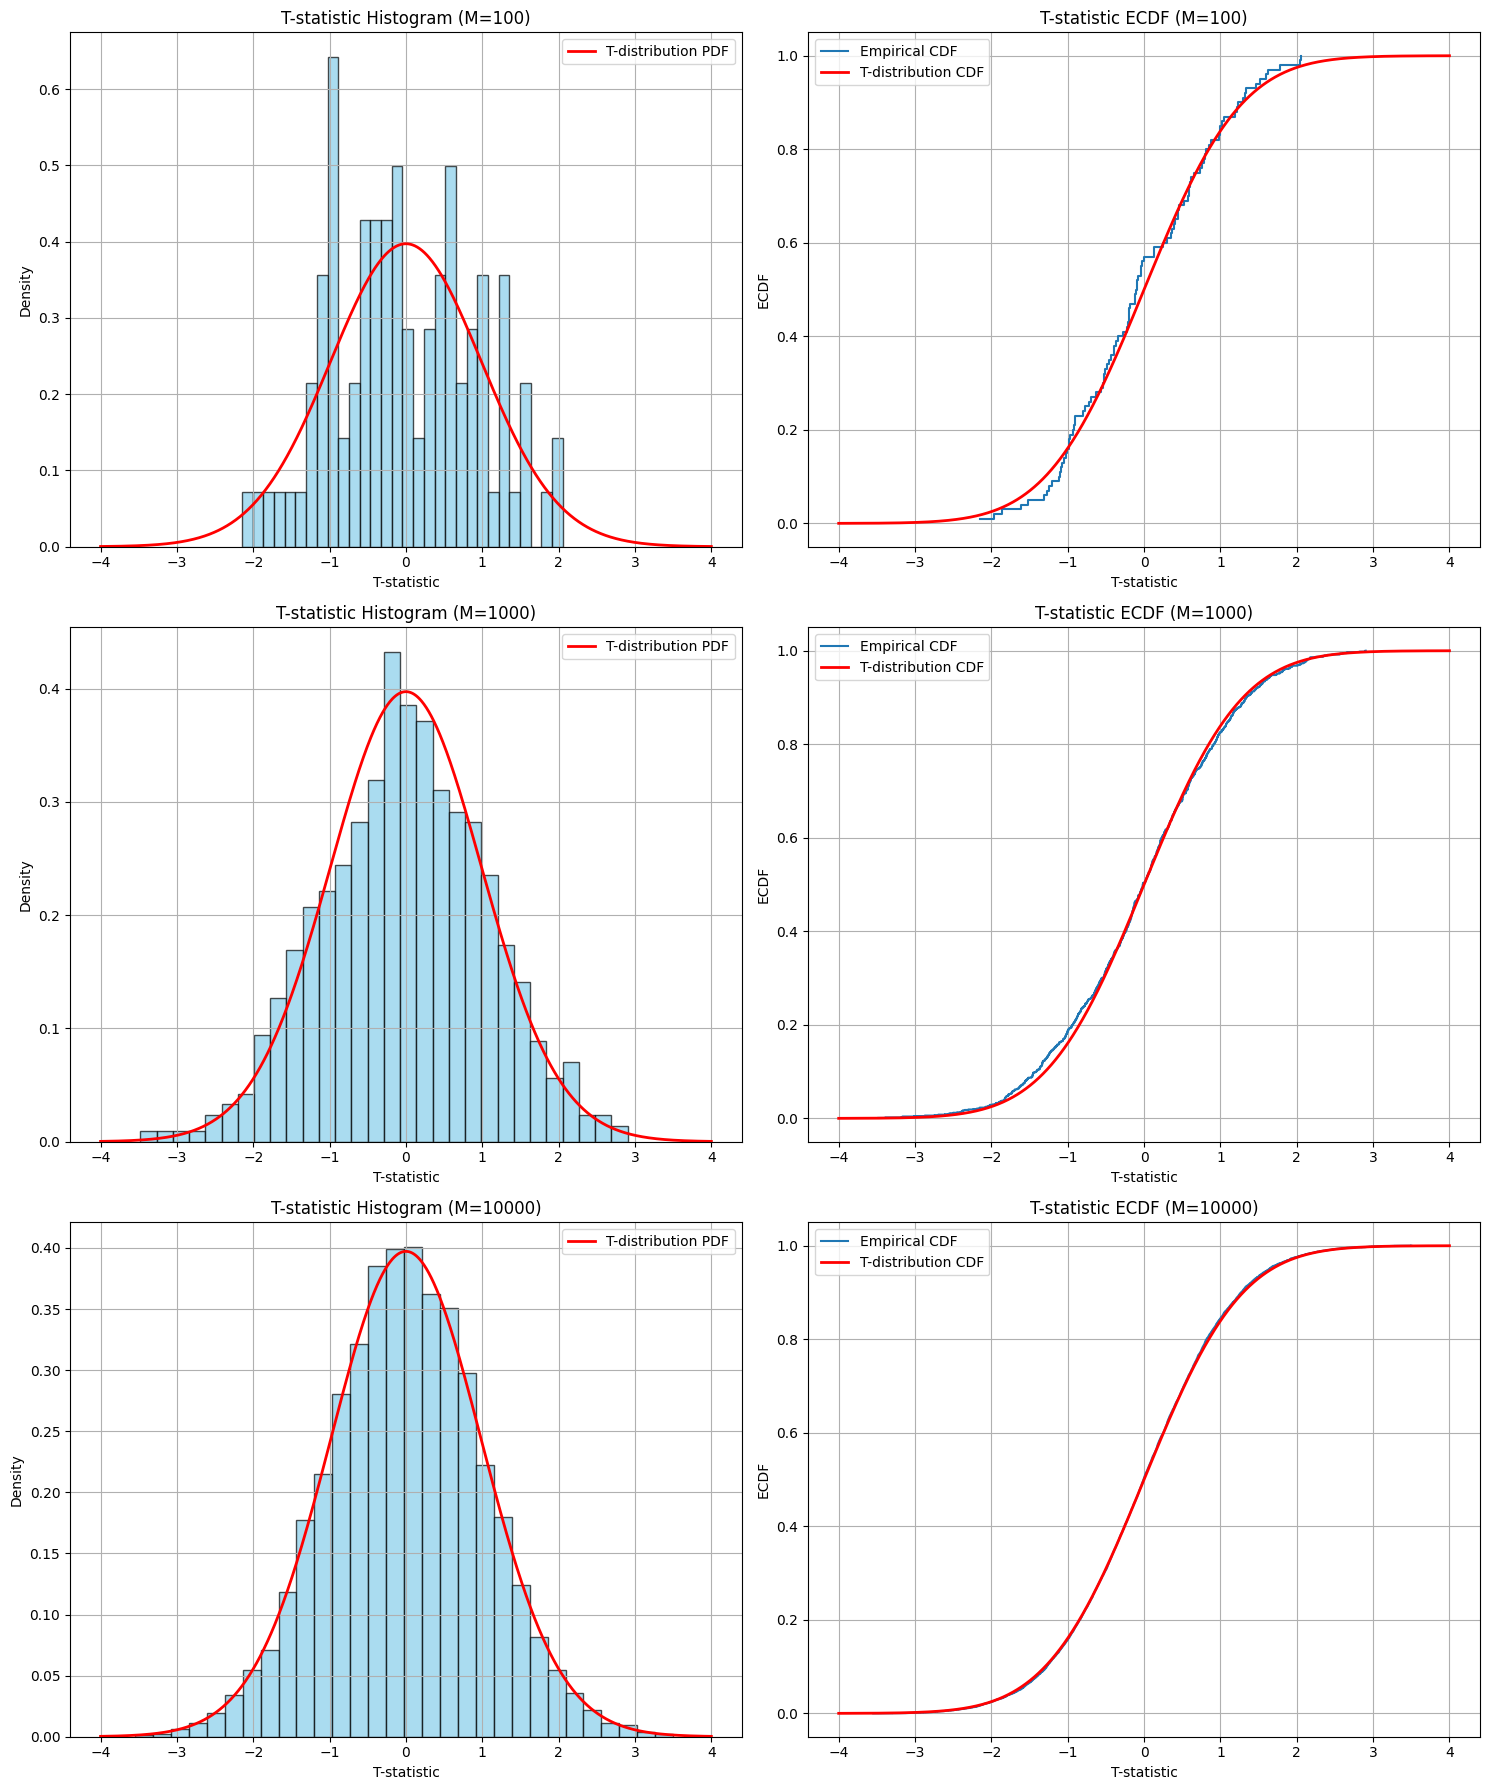

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# 設定實驗參數
M_values = [100, 1000, 10000]  # 重複實驗次數
n1, n2 = 30, 30  # 樣本數
mu1, mu2 = 0, 0  # 均值
sigma1, sigma2 = 1, 1  # 標準差

# 定義 ECDF 函數
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

# 進行實驗並繪製檢定統計量 t 的直方圖與 ECDF 圖
fig, axs = plt.subplots(3, 2, figsize=(15, 18))

for i, M in enumerate(M_values):
    t_values = []
    
    for _ in range(M):
        # 生成兩組標準正態分佈的樣本
        x1 = np.random.normal(mu1, sigma1, n1)
        x2 = np.random.normal(mu2, sigma2, n2)
        
        # 計算樣本均值和標準差
        x1_mean, x2_mean = np.mean(x1), np.mean(x2)
        s1, s2 = np.std(x1, ddof=1), np.std(x2, ddof=1)
        
        # 計算檢定統計量 t
        t_stat = (x1_mean - x2_mean) / np.sqrt(s1**2/n1 + s2**2/n2)
        t_values.append(t_stat)
    
    # 繪製檢定統計量 t 的直方圖
    ax_hist = axs[i, 0]
    ax_hist.hist(t_values, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7)
    x = np.linspace(-4, 4, 1000)
    ax_hist.plot(x, t.pdf(x, df=n1+n2-2), 'r-', lw=2, label='T-distribution PDF')
    ax_hist.set_title(f'T-statistic Histogram (M={M})')
    ax_hist.set_xlabel('T-statistic')
    ax_hist.set_ylabel('Density')
    ax_hist.legend()
    ax_hist.grid(True)
    
    # 繪製檢定統計量 t 的 ECDF 圖
    ax_ecdf = axs[i, 1]
    x_ecdf, y_ecdf = ecdf(t_values)
    ax_ecdf.step(x_ecdf, y_ecdf, where='post', label='Empirical CDF')
    ax_ecdf.plot(x, t.cdf(x, df=n1+n2-2), 'r-', lw=2, label='T-distribution CDF')
    ax_ecdf.set_title(f'T-statistic ECDF (M={M})')
    ax_ecdf.set_xlabel('T-statistic')
    ax_ecdf.set_ylabel('ECDF')
    ax_ecdf.legend()
    ax_ecdf.grid(True)

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 紅線違理論值，用來觀察比對改變抽樣次數，檢定值與實際值的差異，從直方圖中，我們可以看到在M=100時，抽樣分佈的直方圖與紅線理論值形狀幾乎毫不相關，然而在M=10000時，直方圖幾乎與紅線形狀重合，因此可以得知：模擬結果會隨著重複實驗次數的增加而更接近理論分佈。
>- 在ECDF圖中也有同樣的結果，抽樣次數越多，ECDF越重合紅線，模擬的 ECDF 曲線逐漸與理論 CDF 趨於一致。
>- 模擬次數越多，越能減少隨機波動對結果的影響，使模擬結果更準確。




<hr>
<font color=#EF9520> （二） 不同樣本數下「雙（獨立）樣本 T 檢定」之 p-value 值的分配樣態</font>

1. 兩組資料都來自標準常態母體 N(0,1) 且樣本數 n = 10，對這兩組資料進行雙樣本 T 檢定後計算得到一個 p-value 值，並繪製成直方圖觀察其分配樣態。
2. 兩組資料都來自標準常態母體 N(0,1) 且樣本數 n = 30，對這兩組資料進行雙樣本 T 檢定後計算得到一個 p-value 值，並繪製成直方圖觀察其分配樣態。
3. 兩組資料都來自標準常態母體 N(0,1) 且樣本數 n = 100，對這兩組資料進行雙樣本 T 檢定後計算得到一個 p-value 值，並繪製成直方圖觀察其分配樣態。
<hr>

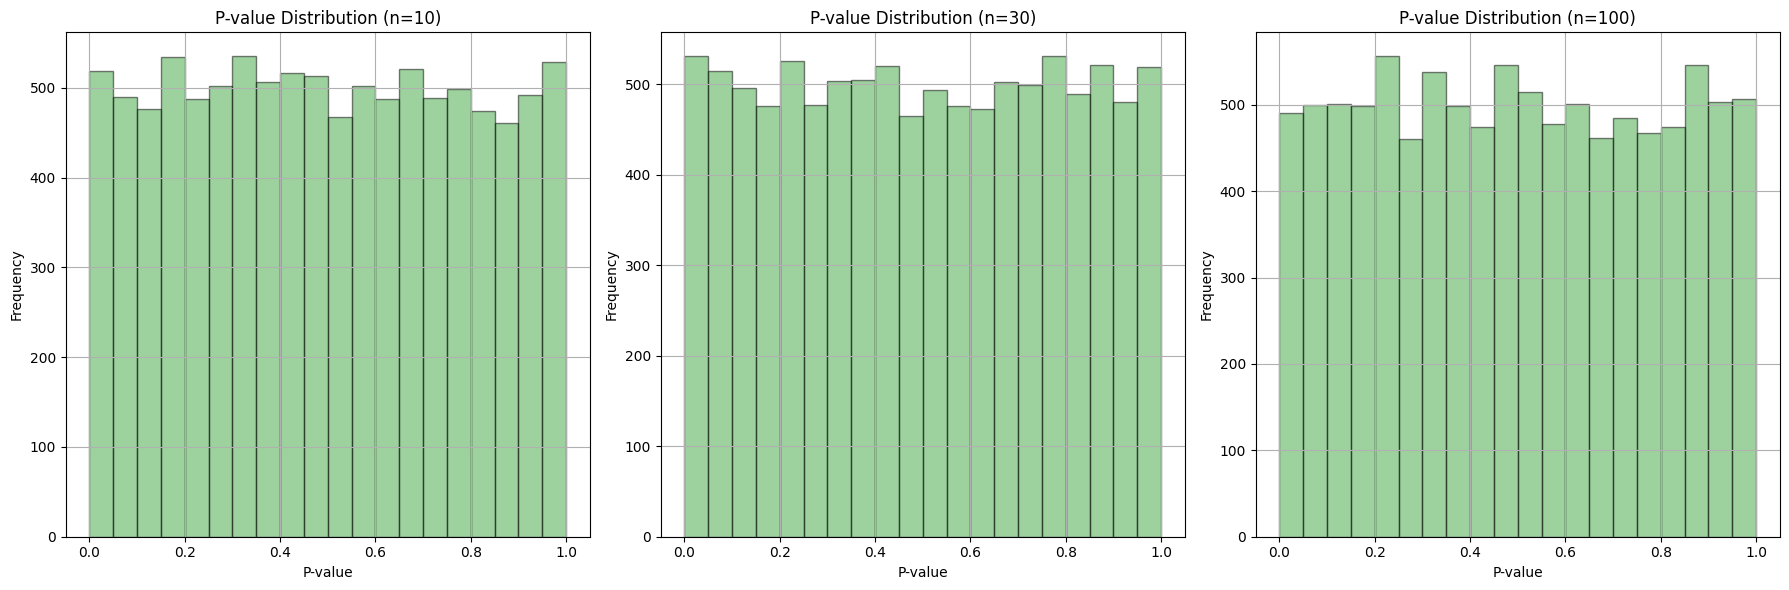

In [5]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# 設定實驗參數
M = 10000  # 重複實驗次數
n_values = [10, 30, 100]  # 樣本數
mu1, mu2 = 0, 0  # 均值
sigma1, sigma2 = 1, 1  # 標準差

# 進行實驗並繪製 p-value 的分佈圖
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, n in enumerate(n_values):
    p_values = []
    
    for _ in range(M):
        # 生成兩組標準正態分佈的樣本
        x1 = np.random.normal(mu1, sigma1, n)
        x2 = np.random.normal(mu2, sigma2, n)
        
        # 進行雙樣本 T 檢定
        t_stat, p_value = ttest_ind(x1, x2, equal_var=True)
        p_values.append(p_value)
    
    # 繪製 p-value 的直方圖
    ax = axs[i]
    ax.hist(p_values, bins=20, color='#3CA43F', edgecolor='black', alpha=0.5)
    ax.set_title(f'P-value Distribution (n={n})')
    ax.set_xlabel('P-value')
    ax.set_ylabel('Frequency')
    ax.grid(True)

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 在虛無假設成立的情況下，無論樣本數為多少，雙樣本t檢定的 p-value 皆接近均勻分布，
>- 在樣本數越大時(n=100)，分佈稍微集中在較高的 p-value 區域。
>- 因兩組資料皆來自N(0, 1)，p-value實為機率，因此可看到 p-value座落在0-1之間並且呈現均勻分布。


<hr>
<font color=#EF9520> （三） 來自不同母體的T-distribution差異示意圖</font>

1. 一組樣本皆來自N(0, 1)的常態分配，另一組樣本皆來自N(0.5, 1)的常態分配，繪製其t分配的pdf線圖，對比兩組不同母體間的差距。
2. 一組樣本皆來自N(0, 1)的常態分配，另一組樣本皆來自N(1.0, 1)的常態分配，繪製其t分配的pdf線圖，對比兩組不同母體間的差距。
3. 一組樣本皆來自N(0, 1)的常態分配，另一組樣本皆來自N(2.0, 1)的常態分配，繪製其t分配的pdf線圖，對比兩組不同母體間的差距。
<hr>

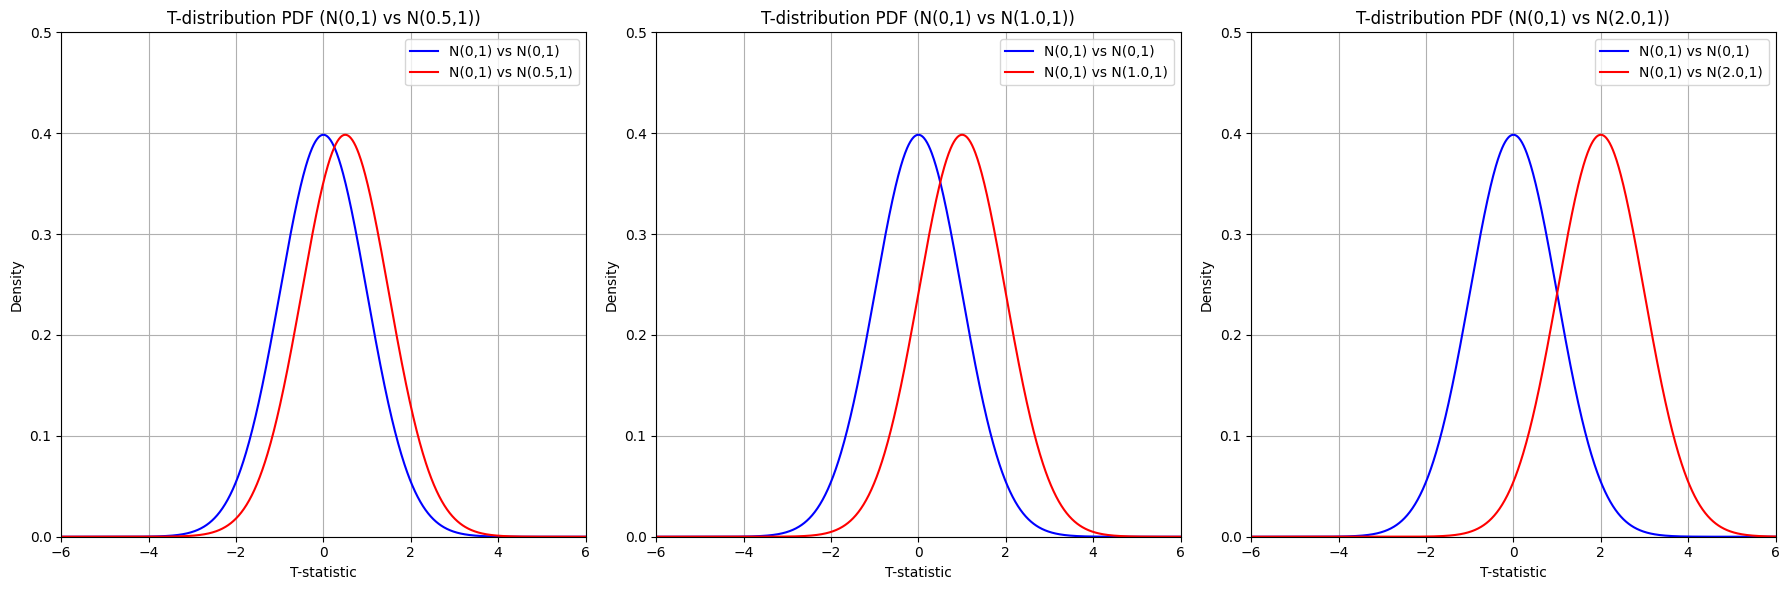

In [137]:
import numpy as np
from scipy.stats import t
import matplotlib.pyplot as plt

# 設定實驗參數
n = 100  # 樣本數
mu1 = 0  # 第一組資料的均值
sigma1 = 1  # 第一組資料的標準差
mu2_values = [0.5, 1.0, 2.0]  # 第二組資料的不同均值
sigma2 = 1  # 第二組資料的標準差

# 繪製理論的 T 分配 PDF
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, mu2 in enumerate(mu2_values):
    ax = axs[i]
    
    # 計算理論的 T 分配 PDF
    df = 2 * (n - 1)  # 自由度
    x = np.linspace(-6, 6, 1000)
    t_pdf_1 = t.pdf(x, df)
    t_pdf_2 = t.pdf(x, df, loc=mu2)

    # 繪製理論的 T 分配 PDF
    ax.plot(x, t_pdf_1, label=f'N(0,1) vs N(0,1)', color='blue')
    ax.plot(x, t_pdf_2, label=f'N(0,1) vs N({mu2},1)', color='red')

    ax.set_title(f'T-distribution PDF (N(0,1) vs N({mu2},1))')
    ax.set_xlabel('T-statistic')
    ax.set_xlim(-6, 6)
    ax.set_ylim(0,  0.5)
    ax.set_ylabel('Density')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 隨著第二組樣本的均值增加，T分配逐漸右移，說明檢定統計量說明檢定統計量t能夠很好地捕捉到均值的增大，並有效地反映兩組間的差異。
>- 當第二組樣本的均值增加時，檢定力顯著提升，因為當均值差異大時，兩組數據間的差異容易被檢測到，顯著性檢定的效果更好。
>- 當樣本間的均值差異增加時，兩組t分配的偏移變得更加明顯，這樣可以有效地識別數據間的均值差異。 


<hr>
<font color=#EF9520> （四）來自不同母體進行雙樣本 T 檢定下的 p-value 分配</font>

1. 假設兩組資料分別來自不同的常態分配 N(0, 1), N(0.1, 1)，生成的資料在雙樣本 T 檢定下，計算其p-value後繪製出直方圖進行比較。
2. 假設兩組資料分別來自不同的常態分配 N(0, 1), N(0.3, 1)，生成的資料在雙樣本 T 檢定下，計算其p-value後繪製出直方圖進行比較。
3. 假設兩組資料分別來自不同的常態分配 N(0, 1), N(0.5, 1)，生成的資料在雙樣本 T 檢定下，計算其p-value後繪製出直方圖進行比較。
4. 假設兩組資料分別來自不同的常態分配 N(0, 1), N(0.8, 1)，生成的資料在雙樣本 T 檢定下，計算其p-value後繪製出直方圖進行比較。
5. 假設兩組資料分別來自不同的常態分配 N(0, 1), N(1.0, 1)，生成的資料在雙樣本 T 檢定下，計算其p-value後繪製出直方圖進行比較。
6. 假設兩組資料分別來自不同的常態分配 N(0, 1), N(2.0, 1)，生成的資料在雙樣本 T 檢定下，計算其p-value後繪製出直方圖進行比較。
<hr>

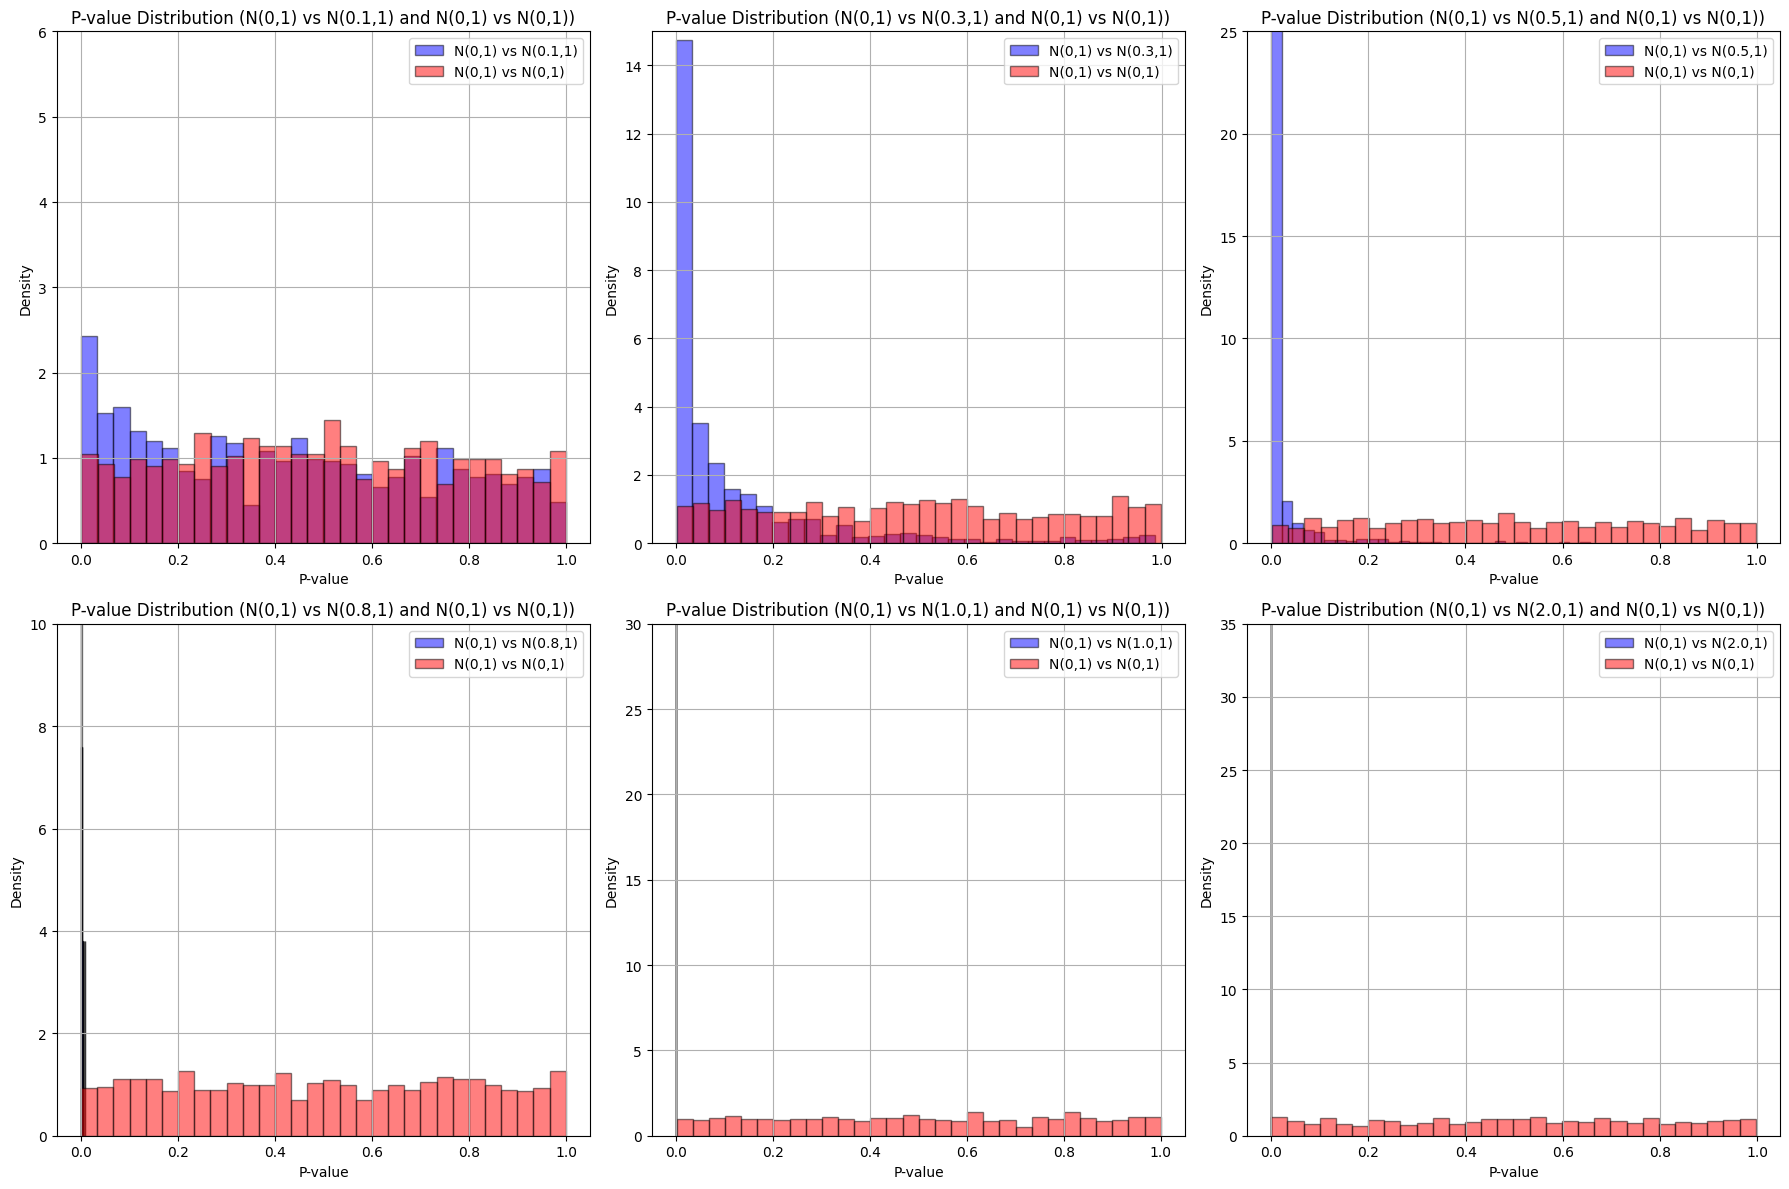

In [141]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# 設定實驗參數
M = 1000  # 重複實驗次數
n1, n2 = 100, 100  # 樣本數
mu1, sigma1 = 0, 1  # 第一組資料的均值和標準差
mu2_values = [0.1, 0.3, 0.5, 0.8, 1.0, 2.0]  # 第二組資料的不同均值
sigma2 = 1  # 第二組資料的標準差

# 進行實驗並繪製 p-value 的分佈圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

for i, mu2 in enumerate(mu2_values):
    p_values_1 = []
    p_values_2 = []
    
    for _ in range(M):
        # 生成兩組標準正態分佈的樣本
        x1 = np.random.normal(mu1, sigma1, n1)
        x2 = np.random.normal(mu2, sigma2, n2)
        x3 = np.random.normal(mu1, sigma1, n1)
        x4 = np.random.normal(mu1, sigma1, n2)
        
        # 進行雙樣本 T 檢定，假設兩樣本的變異數相等
        _, p_value_1 = ttest_ind(x1, x2, equal_var=True)
        _, p_value_2 = ttest_ind(x3, x4, equal_var=True)
        
        # 記錄 p-value
        p_values_1.append(p_value_1)
        p_values_2.append(p_value_2)
    
    # 繪製 p-value 的直方圖
    ax = axs[i // 3, i % 3]
    ax.hist(p_values_1, bins=30, density=True, alpha=0.5, color='blue', edgecolor='black', label=f'N(0,1) vs N({mu2},1)')
    ax.hist(p_values_2, bins=30, density=True, alpha=0.5, color='red', edgecolor='black', label='N(0,1) vs N(0,1)')
    
    ax.set_title(f'P-value Distribution (N(0,1) vs N({mu2},1) and N(0,1) vs N(0,1))')
    ax.set_xlabel('P-value')
    ax.set_ylabel('Density')
    ax.grid(True)
    ax.legend()

    # 單獨調整每個子圖的 y 軸範圍
    if mu2 == 0.1:
        ax.set_ylim(0, 6)
    elif mu2 == 0.3:
        ax.set_ylim(0, 15)
    elif mu2 == 0.5:
        ax.set_ylim(0, 25)
    elif mu2 == 0.8:
        ax.set_ylim(0, 10)
    elif mu2 == 1.0:
        ax.set_ylim(0, 30)
    elif mu2 == 2.0:
        ax.set_ylim(0, 35)

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 由於當樣本來自N(1, 1), N(2, 1)時（均值越大時），p-value過度集中在0附近，難以覺察差異，因此特別做小於0.5的數字逐一比較，較可看得出差異。
>- 實驗（二）得出樣本若皆來自N(0,1)，為均勻分配，從六張圖中可看出，當第二組的均值從 0.1 增加到 2.0 時，藍色直方圖的 p-value）逐漸向低值區域集中。這意味著隨著均值差異的增大，p-value 越來越傾向接近 0，顯示統計檢定能夠有效檢測出兩組之間的顯著差異。
>- 當 $\mu$ 2差異很小（如 $\mu$ 2 = 0.1時），藍色直方圖的 p-value 分佈與紅色分佈重疊較多，因為此時均值差異不足以顯著區分兩組數據。
>- 隨著 $\mu$ 2的增加，檢定的靈敏度也隨之提高，並且 p-value 分佈顯著偏向 0。當 $\mu$ 2 大於 0.5 時，大部分 p-value 小於 0.05，說明檢定力隨均值差異的增加而增強。
>- 當 $\mu$ 2 達到 1.0 或更高時，幾乎所有的 p-value 都接近 0，顯示檢定有極高的成功率拒絕虛無假設。



<hr>
<font color=#EF9520> （五）不同樣本數及檢定力之關係 </font>

1. 假設兩樣本分別來自常態 N(0,1) 與 N(0.5,1)，當樣本數 n1=n2= 10, 20, 30, 50, 100, 300, 500 時，計算檢定力並繪製成折線圖。


<hr>

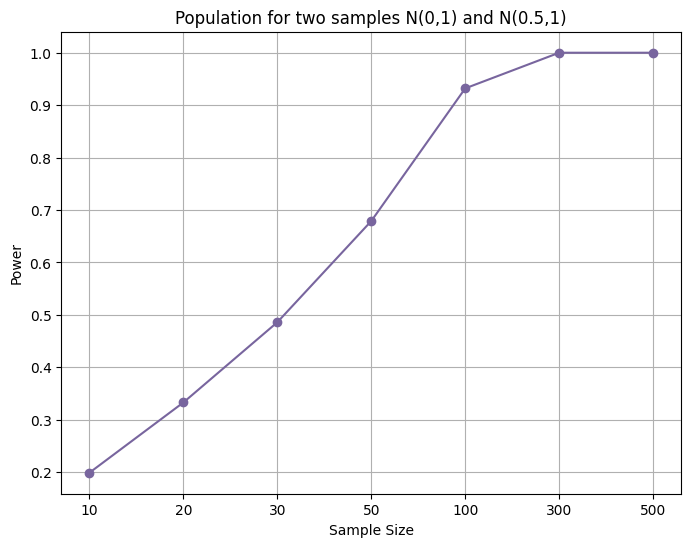

Sample Size: 10, Power: 0.1990
Sample Size: 20, Power: 0.3330
Sample Size: 30, Power: 0.4860
Sample Size: 50, Power: 0.6790
Sample Size: 100, Power: 0.9320
Sample Size: 300, Power: 1.0000
Sample Size: 500, Power: 1.0000


In [67]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# 設定實驗參數
M = 1000  # 重複實驗次數
sample_sizes = [10, 20, 30, 50, 100, 300, 500]  # 樣本數
mu1, sigma1 = 0, 1  # 第一組資料的均值和標準差
mu2, sigma2 = 0.5, 1  # 第二組資料的均值和標準差
alpha = 0.05  # 顯著性水平

# 計算檢定力
powers = []

for n in sample_sizes:
    reject_count = 0
    
    for _ in range(M):
        # 生成兩組標準正態分佈的樣本
        x1 = np.random.normal(mu1, sigma1, n)
        x2 = np.random.normal(mu2, sigma2, n)
        
        # 進行雙樣本 T 檢定，假設兩樣本的變異數相等
        _, p_value = ttest_ind(x1, x2, equal_var=True)
        
        # 計算拒絕虛無假設的次數
        if p_value < alpha:
            reject_count += 1
    
    # 計算檢定力
    power = reject_count / M 
    powers.append(power)

# 繪製樣本數與檢定力的關係圖
plt.figure(figsize=(8, 6))
plt.plot(range(len(sample_sizes)), powers, marker='o', linestyle='-', color='#78659E')
plt.xticks(range(len(sample_sizes)), sample_sizes)
plt.title('Population for two samples N(0,1) and N(0.5,1)')
plt.xlabel('Sample Size')
plt.ylabel('Power')
plt.grid(True)
plt.show()

# 輸出每個樣本檢定力的數值
for n, power in zip(sample_sizes, powers):
    print(f'Sample Size: {n}, Power: {power:.4f}')


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 從折線圖中及輸出值中可看出，當樣本越大，檢定力(power)越大，表示樣本越大越能正確地拒絕虛無假設。
>- 樣本數>=300時，檢定力等於1，幾乎能正確地拒絕虛無假設。
>- 當樣本數足夠大時，檢定力幾乎可達 1，表明在樣本數足夠的情況下，雙樣本t檢定能有效區分均值上的微小差異。
